In [1]:
from IPython.display import HTML
import html
import argparse
from datetime import datetime, timedelta
from pathlib import Path
# Import from demosat_seq package
from demosat_data_utils.ephemeris import EphemerisContainer
from demosat_data_utils.comm_windows import CommWindowContainer
from demosat_data_utils.orbit_events import OrbitEventContainer
from demosat_data_utils.ground_stations import GroundStationContainer
from tts_html_utils.core.compiler import HtmlCompiler
from demosat_plan.demosat_scheduler import DemosatScheduler
from tts_utilities.jnb_util import this_notebook_path

import logging
logging.getLogger().setLevel(logging.WARNING)

2026-025T07:08:32 INFO     2026-025T07:08:32 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=256061;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=450177;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/naif0012.tls                                                                     

                  INFO     2026-025T07:08:32 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=962449;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=493926;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/de430.bsp                                                                        

                  INFO     2026-025T07:08:32 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=437646;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=746605;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/pck00010.tpc                                                                     

                  INFO     2026-025T07:08:32 (INFO) tts_spice.furnish.furnish_kernel: Loaded SPICE   ]8;id=422401;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py\furnish.py]8;;\:]8;id=156844;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/furnish.py#158\158]8;;\
                           kernel:                                                                                 
                           /Users/muszynsk/projects/tt_studio/dev/tts_core/tts_spice/src/tts_spice/k               
                           ernels/earth_latest_high_prec.bpc                                                       

# Orbit Events and Physics

TTS doesn't yet do any sort of spacecraft propagation, so we rely on having fairly frequent ephemeris updates. This assumes that you are working in a system where a nav team or at least a tool like STK is delivering you a predicted ephemeris file to work with.

For this demo, we've downloaded publicly available OCO-2 data from NAIF since that spacecraft has an orbit similar enough to what we want to illustrate using DemoSat.

This demo is focused on showing how you could use such a product to do planning rather than generating it yourself.

In [2]:
ephemeris_path = this_notebook_path().parent.joinpath("ephemeris.txt")
ephem_container = EphemerisContainer(csv_path=ephemeris_path, cast_fields=True)
orbit_events = OrbitEventContainer(ephem=ephem_container)

# Comm Planning
Comm planning is something that TTS would like to take on eventually, but to date we have not, so we are spoofing it as simply as possible. We have defined the available ground stations for DemoSat in demosat_data_utils.GroundStationContainer(). And the __init__ method of CommWindowContainer will calculate which ephemeris data points are in view. It simply treats the first time that is in view for a given window as AOS and the last as LOS. Of course this is cartoonish, but it is future work to make a comm planning library that has higher fidelity. 

CommWindowContainer has a confifurable minimum elevation for windows.

In [3]:
# Create a ground station container with default stations
stations = GroundStationContainer()
min_elevation = 30
comm_windows = CommWindowContainer(ephem=ephem_container, stations=stations, min_el=min_elevation)

# Creating the scheduler
Here we initialize the scheduler. We pass all of the containers from upstream teams and let it go. Because DemoSat is such a simple mission, it has all of the rules to combine these elements within the scheduler. More complex missions may need more arguments passed into each scheduling run.

In [4]:
start_time = min(item.time for item in ephem_container)
end_time = max(item.time for item in ephem_container[:3000])
scheduler = DemosatScheduler(
    start_time=start_time,
    end_time=end_time,
    ephemeris_container=ephem_container,
    comm_window_container=comm_windows,
    orbit_event_container=orbit_events,
)

# Running scheduling.
This cell is meant to be run iteratively so you can explore how the scheduler works. We recommend running them one at a time so you can see the schedule slowly coming to life.

The scheduler.clear_schedule() call at the top will erase any scheduling you've done in the past, so if you keep that line uncommented, the result of this cell should reflect only the uncommented lines.

scheduler.build_schedule() is meant to be how this would be run in production. It simply wraps all of the individual scheduling rounds that we've exposed here. See comments around each round for a brief explanation of what each does.


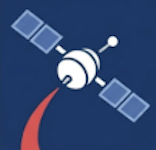

In [5]:
scheduler.clear_schedule() #removes any scheduled events you have added on previous runs of this cell

scheduler.schedule_orbit_events() #schedules Asending/Descending nodes, N/S pole crossings
scheduler.schedule_shadow_events() # schedules terminator crossings
#NOTE: This next one only works if you've also scheduled the last two. But you would never schedule without shadows or orbit events.
#separating it out this way is really just to demo it one step at a time.
scheduler.schedule_orbit_quadrants() # schedules helper activities for scheduling the appropraite science activities at the right times.
scheduler.schedule_adcs_yaw_activities() # schedules a yaw at ascending node crossing and at the north pole to keep solar arays on the sun
scheduler.schedule_comm_windows() # schedules comm windows as delivered by the "comm planning" team above
scheduler.schedule_calibration_activities() #schedules calibration activities at the first descendings node after midnight and noon each day
scheduler.schedule_science_activities() #fills in the rest of the schedule with science appropriate for the right quadrant as defined by N/S hemisphere and Day/Night side

#schedule all of the above. in one call
#scheduler.build_schedule() #does all of the above in one line

compiler = HtmlCompiler(title="Schedule Visualization")
compiler.add_body_component(scheduler.to_gantt_chart())
compiler.render_to_file('schedule_output.html')
HTML(compiler.render_to_jnb_iframe(height='600px'))

# Write the interface file
This demo ends here, but as an example, we show the default JSON file produced by this scheduling tool. It will be used downstream by demosat_seq to build a background sequence from these activities.

In [6]:

scheduler.to_json_file('demosat_schedule_2024_02_02.json')

2026-025T07:08:34 INFO     2026-025T07:08:34 (INFO) tts_plan.scheduler.to_json_file: Scheduler     ]8;id=206144;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_plan/src/tts_plan/scheduler.py\scheduler.py]8;;\:]8;id=901101;file:///Users/muszynsk/projects/tt_studio/dev/tts_core/tts_plan/src/tts_plan/scheduler.py#390\390]8;;\
                           data saved to demosat_schedule_2024_02_02.json                                          

In [7]:
orbit_events[:10]

+----------------------+-----------------------------------+----------------+
| Time                 | Type                              |   Orbit Number |
+======================+===================================+================+
| 2024-033T00:11:29.99 | South Pole Crossing               |           1000 |
+----------------------+-----------------------------------+----------------+
| 2024-033T00:36:12.16 | Ascending Node Crossing           |           1000 |
+----------------------+-----------------------------------+----------------+
| 2024-033T01:00:30.08 | North Pole Crossing               |           1000 |
+----------------------+-----------------------------------+----------------+
| 2024-033T01:02:10.87 | Terminator crossing into shadow   |           1000 |
+----------------------+-----------------------------------+----------------+
| 2024-033T01:25:34.46 | Descending Node Crossing          |           1001 |
+----------------------+-----------------------------------+----------------+
| 2024-033T01:36:56.20 | Terminator crossing out of shadow |           1000 |
+----------------------+-----------------------------------+----------------+
| 2024-033T01:50:29.97 | South Pole Crossing               |           1001 |
+----------------------+-----------------------------------+----------------+
| 2024-033T02:15:05.57 | Ascending Node Crossing           |           1001 |
+----------------------+-----------------------------------+----------------+
| 2024-033T02:39:30.05 | North Pole Crossing               |           1001 |
+----------------------+-----------------------------------+----------------+
| 2024-033T02:41:04.58 | Terminator crossing into shadow   |           1000 |
+----------------------+-----------------------------------+----------------+

In [8]:
comm_windows.sort()[:10]

+---------------------------+----------------+----------------------+----------------------+-----------------+
| Station                   | Abbreviation   | Start Time           | End Time             |   Max Elevation |
+===========================+================+======================+======================+=================+
| McMurdo Station           | MCO            | 2024-033T00:08:00.00 | 2024-033T00:22:00.00 |           41.42 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| Alaska Satellite Facility | ASF            | 2024-033T00:48:00.00 | 2024-033T01:02:00.00 |           60.25 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| Alaska Satellite Facility | ASF            | 2024-033T02:29:00.00 | 2024-033T02:43:00.00 |           43.61 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| Alaska Satellite Facility | ASF            | 2024-033T07:34:00.00 | 2024-033T07:48:00.00 |           32.68 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| Wallops Test Range        | WGS            | 2024-033T08:55:00.00 | 2024-033T09:09:00.00 |           65.57 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| Alaska Satellite Facility | ASF            | 2024-033T09:14:00.00 | 2024-033T09:29:00.00 |           79.82 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| McMurdo Station           | MCO            | 2024-033T16:31:00.00 | 2024-033T16:45:00.00 |           40.06 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| McMurdo Station           | MCO            | 2024-033T18:11:00.00 | 2024-033T18:25:00.00 |           60.41 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| Wallops Test Range        | WGS            | 2024-033T19:16:00.00 | 2024-033T19:30:00.00 |           45.14 |
+---------------------------+----------------+----------------------+----------------------+-----------------+
| McMurdo Station           | MCO            | 2024-033T19:51:00.00 | 2024-033T20:06:00.00 |           76.93 |
+---------------------------+----------------+----------------------+----------------------+-----------------+

In [9]:
ephem_container[:10]

+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
|          JD | Time                             |        x |         y |        z |     v_x |      v_y |      v_z | planet   |
+=============+==================================+==========+===========+==========+=========+==========+==========+==========+
| 2.46034e+06 | A.D. 2024-Feb-02 00:00:00.000000 | -4780.11 |  896.914  | -5155.2  | 4.59311 | -3.39333 | -4.85475 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:01:00.000000 | -4495.09 |  691.655  | -5435.89 | 4.90432 | -3.44631 | -4.49865 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:02:00.000000 | -4191.99 |  483.634  | -5694.68 | 5.19566 | -3.48538 | -4.12458 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:03:00.000000 | -3872.03 |  273.689  | -5930.52 | 5.46596 | -3.5104  | -3.73407 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:04:00.000000 | -3536.51 |   62.6675 | -6142.47 | 5.71417 | -3.52129 | -3.32869 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:05:00.000000 | -3186.79 | -148.582  | -6329.7  | 5.93933 | -3.51801 | -2.91008 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:06:00.000000 | -2824.27 | -359.211  | -6491.45 | 6.14054 | -3.50059 | -2.47994 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:07:00.000000 | -2450.42 | -568.373  | -6627.09 | 6.31704 | -3.46911 | -2.03997 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:08:00.000000 | -2066.73 | -775.227  | -6736.09 | 6.46813 | -3.42372 | -1.59196 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+
| 2.46034e+06 | A.D. 2024-Feb-02 00:09:00.000000 | -1674.76 | -978.945  | -6818    | 6.59324 | -3.3646  | -1.13767 | EARTH    |
+-------------+----------------------------------+----------+-----------+----------+---------+----------+----------+----------+